In [ ]:
!pip install -U langchain langchain-core==1.0 langchain-community langchain-experimental langchain_google_genai

INFO: pip is looking at multiple versions of langchain to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 2.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-google-genai to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-classic to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-text-splitters to determine which version is compatible with other requirements. This could take a

### Build a Simple Workflow or Graph Using LangGraph

**State**
First, define the State of the graph.

The State schema serves as the input schema for all Nodes and Edges in the graph.

Let's use the TypedDict class from python's typing module as our schema, which provides type hints for the keys.

In [ ]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info:str

**Nodes** :
Nodes are just python functions.

The first positional argument is the state, as defined above.

Because the state is a TypedDict with schema as defined above, each node can access the key, graph_state, with state['graph_state'].

Each node returns a new value of the state key graph_state.

By default, the new value returned by each node will override the prior state value.

In [ ]:
def start_play(state:State):
    print("Start_Play node has been called")
    return {"graph_info":state['graph_info'] + " I am planning to play"}

def cricket(state:State):
    print("My Cricket node has been called")
    return {"graph_info":state['graph_info'] + " Cricket"}

def badminton(state:State):
    print("My badminton node has been called")
    return {"graph_info":state['graph_info'] + " Badminton"}

In [ ]:
import random
from typing import Literal

def random_play(state:State)-> Literal['cricket','badminton']:
    graph_info=state['graph_info']

    if random.random()>0.5:
        return "cricket"
    else:
        return "badminton"

**Graph Construction**
Now, we build the graph from our components defined above.

The StateGraph class is the graph class that we can use.

First, we initialize a StateGraph with the State class we defined above.

Then, we add our nodes and edges.

We use the START Node, a special node that sends user input to the graph, to indicate where to start our graph.

The END Node is a special node that represents a terminal node.

Finally, we compile our graph to perform a few basic checks on the graph structure.

We can visualize the graph as a Mermaid diagram.

In [ ]:
!pip install langgraph

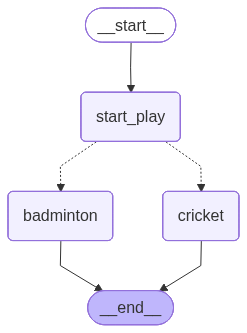

In [ ]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

## Build Graph
graph=StateGraph(State)

## Adding the nodes
graph.add_node("start_play",start_play)
graph.add_node("cricket",cricket)
graph.add_node("badminton",badminton)

## Schedule the flow of the graph

graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("cricket",END)
graph.add_edge("badminton",END)

## Compile the graph
graph_builder=graph.compile()

## View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

**GRAPH Invocation**

In [ ]:
graph_builder.invoke({"graph_info":"Hey My name is Alex"})

Start_Play node has been called
My badminton node has been called


{'graph_info': 'Hey My name is Alex I am planning to play Badminton'}

### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


In [ ]:
import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"]=userdata.get('gemini_key')
#genai.configure(api_key=userdata.get('gemini_key'))

from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [ ]:
!pip install arxiv

api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 1.7 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=945e4ac351b9f8baa243357226274af030aec8852fc9e0ef016ea9c6883dd9c6
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
arxiv


In [ ]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [ ]:
!pip install wikipedia

api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=7192095bf526808de5673b8607c69d6eb40f2e9aae402096904633cfbb93114e
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


'wikipedia'

In [ ]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [ ]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b


In [ ]:
os.environ["TAVILY_API_KEY"]=userdata.get('tavily_key')

### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/tmp/ipython-input-321048985.py:6: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [ ]:
tavily.invoke("Provide me the recent AI news for Jan 3rd 2026")

[{'title': 'Weekly AI News January 3 2026: The Pulse And The Pattern',
  'url': 'https://www.youtube.com/watch?v=ox4m9J-zBHA',
  'content': "Read the full article: https://binaryverseai.com/ai-news-january-3-2026-15-weekly-updates-roundup/ This week in AI didn't feel like a tidy",
  'score': 0.8312667},
 {'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': 'Source: Fox News ↗\n\n### Alaska Court System Limits AI Chatbot Usage After Technical Difficulties\n\nDate: January 3, 2026 [...] Summary: At CES 2026, AMD announced a major expansion of its hardware lineup, introducing the Ryzen AI 400 series processors for laptops and providing new details on its next-generation "Turin" data center chips. The new PC processors feature an upgraded Neural Processing Unit (NPU) designed to significantly accelerate local AI tasks like real-time translation and content creation. AMD\'s latest dat

In [ ]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily,add,divide,multiply]

In [ ]:
## Initialize my LLM model

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

llm_with_tools=llm.bind_tools(tools)

In [ ]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "recent AI news"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--ecbaf359-a0d6-4322-a39d-b35c69ecb9e8-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': '46f6840b-082e-4fa3-b066-bc50b37b5dc0', 'type': 'tool_call'}], usage_metadata={'input_tokens': 381, 'output_tokens': 23, 'total_tokens': 404, 'input_token_details': {'cache_read': 0}})

In [ ]:
#llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls
#llm_with_tools.invoke([HumanMessage(content=f"What is the theory of relativity")]).tool_calls
#llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2?")]).tool_calls
#llm_with_tools.invoke([HumanMessage(content=f"top 2 articles on psychoanalysis")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'venezuela recent news'},
  'id': 'ea04ee54-e1c4-428b-b042-0a89db633101',
  'type': 'tool_call'}]

In [ ]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

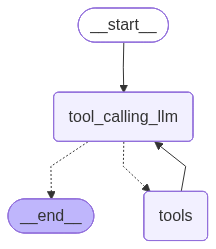

In [ ]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5. Then multiply by 10. I also want to know about gravity and good articles on self attention")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5. Then multiply by 10. I also want to know about gravity and good articles on self attention
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fdce3a6e-5992-4380-b641-c4bca6ca07f6)
 Call ID: fdce3a6e-5992-4380-b641-c4bca6ca07f6
  Args:
    query: AI news March 3rd 2025
  add (3a720aed-f857-426a-8aa4-f715690c423a)
 Call ID: 3a720aed-f857-426a-8aa4-f715690c423a
  Args:
    a: 5
    b: 5
  multiply (0a22b781-9c06-4be7-aea3-217dcffa29c0)
 Call ID: 0a22b781-9c06-4be7-aea3-217dcffa29c0
  Args:
    a: 10
    b: 10
  wikipedia (469fcf33-5c3d-4640-b305-85855964ad62)
 Call ID: 469fcf33-5c3d-4640-b305-85855964ad62
  Args:
    query: gravity
  arxiv (0b915345-ec58-4c61-ac71-3544598622a4)
 Call ID: 0b915345-ec58-4c61-ac71-3544598622a4
  Args:
    query: self attention
===========

In [ ]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (c3874ba0-bf56-411e-adef-99313be8c855)
 Call ID: c3874ba0-bf56-411e-adef-99313be8c855
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
================================== Ai Message =====================

### Add Memory to Agents

In [ ]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (ce3aed7c-38e2-4979-a985-e0ba8951c249)
 Call ID: ce3aed7c-38e2-4979-a985-e0ba8951c249
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================


In [ ]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

Sure, I can help with that. What is the number you would like to divide by 5?


**MemorySaver**

LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [ ]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


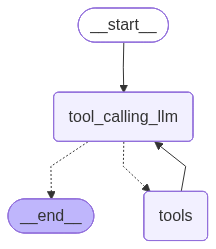

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [ ]:
## Specify the thread

config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (f3f69f27-5472-4196-84d1-1c59a4063dbc)
 Call ID: f3f69f27-5472-4196-84d1-1c59a4063dbc
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================


In [ ]:
messages = [HumanMessage(content="add that number to 25")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (f3f69f27-5472-4196-84d1-1c59a4063dbc)
 Call ID: f3f69f27-5472-4196-84d1-1c59a4063dbc
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (7fa4a42c-ce04-4b4a-aba1-a4c5958c6269)
 Call ID: 7fa4a42c-ce04-4b4a-aba1-a4c5958c6269
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================


In [ ]:
messages = [HumanMessage(content="then multiplty that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (f3f69f27-5472-4196-84d1-1c59a4063dbc)
 Call ID: f3f69f27-5472-4196-84d1-1c59a4063dbc
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (7fa4a42c-ce04-4b4a-aba1-a4c5958c6269)
 Call ID: 7fa4a42c-ce04-4b4a-aba1-a4c5958c6269
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================
=====================